# SuppFig — SBS1 exposure stability under downsampling (trunk)

Boxplots of normalized SBS1 exposure across bootstrap downsamplings of each sample's truncal mutations, vs detection power (downsampled TMB / total truncal burden). The red dashed line is the full (undownsampled) trunk exposure. Samples: BTE1, BTE4, BTH4, BTH5, BTT4, BTT7 (`nBoot = 200`).

All inputs live in `data/SuppFig_trunk_SBS1_stability_downsampling/`:
- `trunk_vcfs/{SAMPLE}_trunk.vcf` — truncal SNV calls per sample.
- `trunk_SBS96_categories.csv` — each SNV pre-annotated to its SBS96 channel.
- `W_extended_v4_BasicSet.csv` — the cohort SBS catalog used for refitting.
- `trunk_bootstrap_exposures.csv` — the cached long-form result plotted below.

Pipeline: downsample each trunk at `TMB = 10..200` (`nBoot = 200`), build SBS96 spectra, refit with `musical.refit.refit(method='likelihood_bidirectional', thresh=0.001)`, take `H_reduced_normalized`. Per-sample × per-TMB summary stats are exported as `SupTable2_trunk_signature_stability_downsampling.xlsx`.

In [1]:
# --- Nature figure style: 0.25 lw spines/ticks, no top/right spines ---
import matplotlib as mpl
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "font.size": 9,
    "axes.linewidth": 0.25,
    "xtick.major.width": 0.25, "ytick.major.width": 0.25,
    "xtick.minor.width": 0.25, "ytick.minor.width": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

def nature_axes(ax, keep_top=False):
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(keep_top)
    for sp in ax.spines.values():
        sp.set_linewidth(0.25)
    ax.tick_params(width=0.25)
    return ax

## 1. Regenerate the bootstrap exposures (commented out — already cached)

Uncomment to rebuild `data/SuppFig_trunk_SBS1_stability_downsampling/trunk_bootstrap_exposures.csv` (~30 s), using only files in that folder.

In [2]:
# import numpy as np, pandas as pd, musical
#
# np.random.seed(0)
# SIZES = list(range(10, 210, 10)); NBOOT = 200
#
# W        = pd.read_csv("data/SuppFig_trunk_SBS1_stability_downsampling/W_extended_v4_BasicSet.csv").set_index("Mutation")
# CHANNELS = list(W.index); ch_idx = {c: i for i, c in enumerate(CHANNELS)}
# cats_all = pd.read_csv("data/SuppFig_trunk_SBS1_stability_downsampling/trunk_SBS96_categories.csv")
#
# def spectrum(idx_array):
#     v = np.zeros(len(CHANNELS)); u, cnt = np.unique(idx_array, return_counts=True); v[u] = cnt
#     return v
#
# frames = []
# for sample, grp in cats_all.groupby("Sample"):
#     cats = grp["Channel"].map(ch_idx).to_numpy(); total_burden = len(cats)
#     cols, mats = ["original"], [spectrum(cats)]
#     for size in SIZES:
#         for sim in range(1, NBOOT + 1):
#             sub = np.random.choice(cats, size=min(size, total_burden), replace=False)
#             cols.append(f"{size}_{sim}"); mats.append(spectrum(sub))
#     X = pd.DataFrame(np.array(mats).T, index=CHANNELS, columns=cols)
#     X = X.loc[:, X.sum() != 0]
#     _, model = musical.refit.refit(X, W, method="likelihood_bidirectional", thresh=0.001)
#     Hn = model.H_reduced_normalized
#     df = Hn.T.reset_index().melt(id_vars=["index"], var_name="Signature", value_name="Value")
#     df["Original"]     = df["Signature"].map(Hn["original"])
#     df["Total_Burden"] = total_burden
#     df["Sample"]       = sample
#     frames.append(df)
# pd.concat(frames, ignore_index=True).to_csv("data/SuppFig_trunk_SBS1_stability_downsampling/trunk_bootstrap_exposures.csv", index=False)

## 2. Load the cached exposures and export the summary supplemental table


In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

SAMPLES   = ["BTE1", "BTE4", "BTH4", "BTH5", "BTT4", "BTT7"]
SIGNATURE = "SBS1"
OUT = "../output/SuppFig_trunk_SBS1_stability_downsampling"
os.makedirs(OUT, exist_ok=True)

exposures = pd.read_csv("data/SuppFig_trunk_SBS1_stability_downsampling/trunk_bootstrap_exposures.csv")
print("rows:", len(exposures), "| samples:", sorted(exposures["Sample"].unique()))
print("total truncal burden per sample (SNVs):")
print(exposures.groupby("Sample")["Total_Burden"].first().to_string())
exposures.head()

rows: 264066 | samples: ['BTE1', 'BTE4', 'BTH4', 'BTH5', 'BTT4', 'BTT7']
total truncal burden per sample (SNVs):
Sample
BTE1    1267
BTE4    3773
BTH4    9493
BTH5    1581
BTT4     995
BTT7    1058


,index,Signature,Value,Original,Total_Burden,Sample
0,original,SBS1,0.105562,0.105562,1267,BTE1
1,10_1,SBS1,0.108480,0.105562,1267,BTE1
2,10_2,SBS1,0.052225,0.105562,1267,BTE1
3,10_3,SBS1,0.114834,0.105562,1267,BTE1
4,10_4,SBS1,0.000000,0.105562,1267,BTE1


In [4]:
# Per-sample, per-TMB summary statistics for every signature -> supplemental table.
boot = exposures[exposures["index"] != "original"].copy()
boot["TMB"] = boot["index"].str.split("_", expand=True)[0].astype(int)

summary = (boot.groupby(["Sample", "Signature", "TMB"])["Value"]
               .agg(n="size", mean="mean", std="std", median="median",
                    q25=lambda s: s.quantile(.25), q75=lambda s: s.quantile(.75),
                    q05=lambda s: s.quantile(.05), q95=lambda s: s.quantile(.95))
               .reset_index())
tb   = exposures.groupby("Sample")["Total_Burden"].first()
orig = exposures[exposures["index"] == "original"].set_index(["Sample", "Signature"])["Value"]
summary["Total_Burden"]        = summary["Sample"].map(tb)
summary["Detection_Power"]     = np.round(summary["TMB"] / summary["Total_Burden"], 3)
summary["Original_full_trunk"] = summary.set_index(["Sample", "Signature"]).index.map(orig)
for col in ["mean", "std", "median", "q25", "q75", "q05", "q95", "Original_full_trunk"]:
    summary[col] = summary[col].round(4)
summary = summary[["Sample", "Signature", "TMB", "Detection_Power", "Total_Burden", "n",
                   "mean", "std", "median", "q25", "q75", "q05", "q95",
                   "Original_full_trunk"]].sort_values(["Sample", "Signature", "TMB"])

os.makedirs("../supplemental_tables_v2", exist_ok=True)
summary.to_excel("../supplemental_tables_v2/SupTable2_trunk_signature_stability_downsampling.xlsx",
                 index=False)
print("summary shape:", summary.shape, "| signatures:", summary["Signature"].nunique())
summary[summary["Signature"] == SIGNATURE].head(10)

summary shape: (1320, 14) | signatures: 11


,Sample,Signature,TMB,Detection_Power,Total_Burden,n,mean,std,median,q25,q75,q05,q95,Original_full_trunk
0,BTE1,SBS1,10,0.008,1267,200,0.1051,0.1076,0.0896,0.0000,0.1678,0.0000,0.3076,0.1056
1,BTE1,SBS1,20,0.016,1267,200,0.1016,0.0852,0.0875,0.0265,0.1532,0.0000,0.2658,0.1056
2,BTE1,SBS1,30,0.024,1267,200,0.1059,0.0645,0.1001,0.0577,0.1457,0.0000,0.2252,0.1056
3,BTE1,SBS1,40,0.032,1267,200,0.1065,0.0651,0.1014,0.0556,0.1453,0.0130,0.2173,0.1056
4,BTE1,SBS1,50,0.039,1267,200,0.1063,0.0546,0.1008,0.0682,0.1373,0.0261,0.1999,0.1056
5,BTE1,SBS1,60,0.047,1267,200,0.1066,0.0492,0.1022,0.0750,0.1384,0.0290,0.1901,0.1056
6,BTE1,SBS1,70,0.055,1267,200,0.0993,0.0422,0.0940,0.0676,0.1333,0.0359,0.1722,0.1056
7,BTE1,SBS1,80,0.063,1267,200,0.1045,0.0398,0.1029,0.0745,0.1276,0.0487,0.1747,0.1056
8,BTE1,SBS1,90,0.071,1267,200,0.1073,0.0414,0.1066,0.0819,0.1350,0.0367,0.1751,0.1056
9,BTE1,SBS1,100,0.079,1267,200,0.1000,0.0356,0.0978,0.0765,0.1214,0.0452,0.1620,0.1056


## 3. Plot

Bottom axis = detection power, top axis = target TMB; the full-trunk exposure is the red
dashed line. The top spine is kept because it carries the Target-TMB axis.

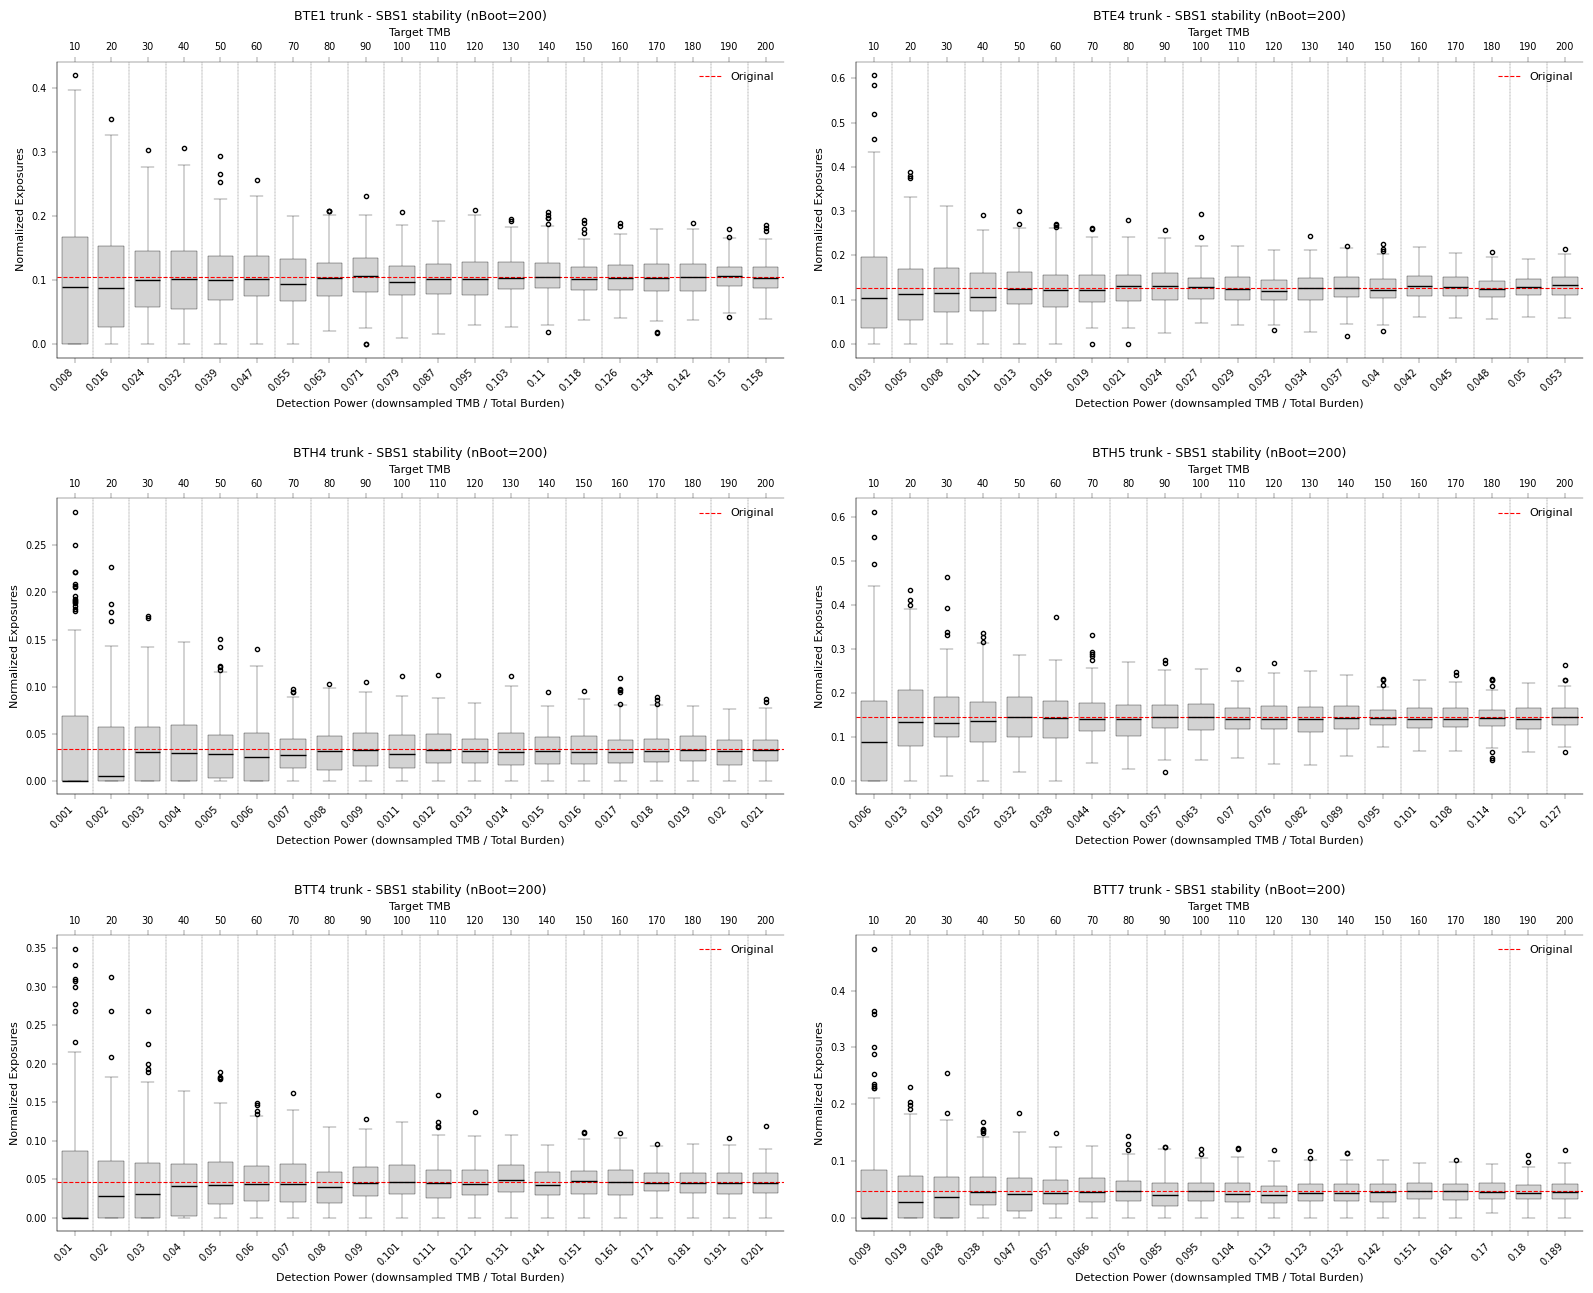

In [5]:
def plot_stability(df, sample_name, signature, ax):
    df_sig = df[df["Signature"] == signature].copy()
    b      = df_sig[df_sig["index"] != "original"].copy()
    b["TMB"] = b["index"].str.split("_", expand=True)[0].astype(int)
    b["Detection_Power"] = np.round(b["TMB"] / b["Total_Burden"], 3)
    o = df_sig.loc[df_sig["index"] == "original", "Original"]
    original_value = o.iloc[0] if not o.empty else None

    sns.boxplot(data=b, x="Detection_Power", y="Value", color="lightgrey", ax=ax,
                fliersize=3.0, width=0.7,
                boxprops=dict(edgecolor="black", linewidth=0.25),
                whiskerprops=dict(color="black", linewidth=0.25),
                capprops=dict(color="black", linewidth=0.25),
                medianprops=dict(color="black", linewidth=1.0),
                flierprops=dict(markeredgecolor="black", linewidth=0.2))
    if original_value is not None:
        ax.axhline(y=original_value, color="red", linestyle="--", linewidth=0.8, label="Original")

    ax.set_xlabel("Detection Power (downsampled TMB / Total Burden)", fontsize=8)
    ax.set_ylabel("Normalized Exposures", fontsize=8)
    ax.set_title(f"{sample_name} trunk - {signature} stability (nBoot=200)", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    ax.legend(loc="upper right", frameon=False, fontsize=8)

    tmb_values = sorted(b["TMB"].unique())
    xticks = ax.get_xticks()
    ax2 = ax.twiny()
    if len(tmb_values) == len(xticks):
        ax2.set_xticks(xticks); ax2.set_xticklabels(tmb_values, fontsize=7)
        ax2.set_xlabel("Target TMB", fontsize=8); ax2.set_xlim(ax.get_xlim())
        for i in range(1, len(xticks)):
            ax.axvline(x=(xticks[i-1] + xticks[i]) / 2, color="black", linestyle="--", linewidth=0.2)
    nature_axes(ax, keep_top=True)          # keep top spine for the Target-TMB axis
    ax2.spines["right"].set_visible(False)
    for sp in ax2.spines.values():
        sp.set_linewidth(0.25)
    ax2.tick_params(width=0.25)

fig, axes = plt.subplots(3, 2, figsize=(16, 13))
for ax, sample in zip(axes.flatten(), SAMPLES):
    plot_stability(exposures[exposures["Sample"] == sample], sample, SIGNATURE, ax)
fig.tight_layout(h_pad=3.0, w_pad=2.5)      # avoid title/top-axis overlap between rows
fig.savefig(f"{OUT}/SuppFig_trunk_{SIGNATURE}_stability.pdf", dpi=700, bbox_inches="tight")
plt.show()